In [1]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from torch.cuda.amp import autocast
import time

In [2]:
# ===================== 1. EARLY STOPPING =====================

class EarlyStopping:
    def __init__(self, patience=12, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [3]:
# ===================== 2. DEVICE & AMP CONFIG =====================

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    torch.backends.cudnn.benchmark = True

use_amp = (device == "cuda")
if use_amp:
    scaler = torch.amp.GradScaler("cuda")
else:
    scaler = None

Using device: cuda


In [4]:
# ===================== 3. TRANSFORMS =====================

train_transform = transforms.Compose([
    transforms.Resize((1024,256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((1024,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ===================== 4. DATASET & SPLIT =====================

data_root = "/kaggle/input/rice-deficiency-dataset"

# 1. Dataset cho TRAIN (có augmentation)
ds_full_train = ImageFolder(data_root, transform=train_transform)

# 2. Dataset cho VAL/TEST (không augmentation)
ds_full_eval = ImageFolder(data_root, transform=eval_transform)

# Lấy labels để chia Stratified
labels = np.array(ds_full_eval.targets)

# Stratified split: 10% Test cố định
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
trainval_idx, test_idx = next(splitter.split(np.zeros(len(labels)), labels))

# Test set cố định
test_ds = Subset(ds_full_eval, test_idx)

# Labels dùng cho K-Fold trên phần train+val
trainval_labels = labels[trainval_idx]

In [5]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

def create_mobilenetv3_partial(num_classes=3, unfreeze_last_n_blocks=3):
    """
    MobileNetV3-Large partial fine-tune:
    - Freeze toàn bộ
    - Unfreeze classifier
    - Unfreeze N block cuối của features
    """
    weights = MobileNet_V3_Large_Weights.DEFAULT
    model = mobilenet_v3_large(weights=weights)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    # 1) Freeze tất cả
    for param in model.parameters():
        param.requires_grad = False

    # 2) Unfreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

    # 3) Unfreeze N block cuối
    if unfreeze_last_n_blocks > 0:
        for block in model.features[-unfreeze_last_n_blocks:]:
            for param in block.parameters():
                param.requires_grad = True

    return model


In [6]:
tmp_model = create_mobilenetv3_partial(num_classes=3, unfreeze_last_n_blocks=2).to(device)
print(tmp_model)

total_params = sum(p.numel() for p in tmp_model.parameters())
trainable_params = sum(p.numel() for p in tmp_model.parameters() if p.requires_grad)

print(f"Total parameters:      {total_params:,}")
print(f"Trainable parameters:  {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 144MB/s] 


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [7]:
# ===================== 6. K-FOLD TRAINING CONFIG =====================

batch_size = 32
num_epochs = 100
base_lr = 1e-4   # LR nhỏ hơn vì dùng pretrained
n_splits = 5

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

results = []
best_overall_acc = 0
best_overall_state = None
best_overall_fold = None

# Test loader có thể tạo 1 lần
test_loader = DataLoader(test_ds, batch_size=batch_size,
                         shuffle=False, num_workers=2, pin_memory=True)

fold = 1



=============== FOLD 1/5 ===============
Epoch 1/100 | Train Loss: 0.9545 | Val Loss: 0.8960 | Val Acc: 0.5817
Epoch 2/100 | Train Loss: 0.5432 | Val Loss: 0.6862 | Val Acc: 0.6298
Epoch 3/100 | Train Loss: 0.2998 | Val Loss: 0.5384 | Val Acc: 0.7644
Epoch 4/100 | Train Loss: 0.2267 | Val Loss: 0.3872 | Val Acc: 0.8462
Epoch 5/100 | Train Loss: 0.1878 | Val Loss: 0.3539 | Val Acc: 0.8798
Epoch 6/100 | Train Loss: 0.1671 | Val Loss: 0.3034 | Val Acc: 0.8990
Epoch 7/100 | Train Loss: 0.1265 | Val Loss: 0.2403 | Val Acc: 0.9038
Epoch 8/100 | Train Loss: 0.1070 | Val Loss: 0.1622 | Val Acc: 0.9423
Epoch 9/100 | Train Loss: 0.1028 | Val Loss: 0.1922 | Val Acc: 0.9231
Epoch 10/100 | Train Loss: 0.1042 | Val Loss: 0.1366 | Val Acc: 0.9712
Epoch 11/100 | Train Loss: 0.0775 | Val Loss: 0.1236 | Val Acc: 0.9519
Epoch 12/100 | Train Loss: 0.0742 | Val Loss: 0.1075 | Val Acc: 0.9615
Epoch 13/100 | Train Loss: 0.0669 | Val Loss: 0.1082 | Val Acc: 0.9567
Epoch 14/100 | Train Loss: 0.0617 | Val Loss

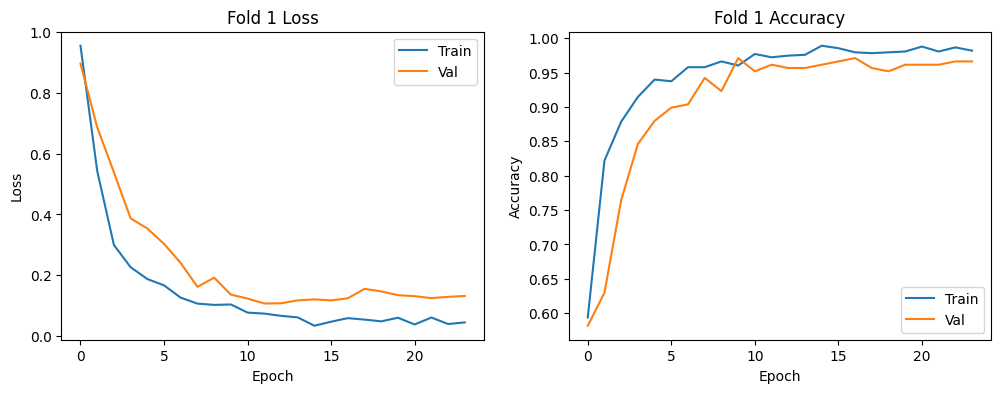


>>> Test Accuracy Fold 1: 0.9655
               precision    recall  f1-score   support

  Nitrogen(N)       1.00      1.00      1.00        44
Phosphorus(P)       0.91      0.97      0.94        33
 Potassium(K)       0.97      0.92      0.95        39

     accuracy                           0.97       116
    macro avg       0.96      0.96      0.96       116
 weighted avg       0.97      0.97      0.97       116


=============== FOLD 2/5 ===============
Epoch 1/100 | Train Loss: 0.9388 | Val Loss: 0.9660 | Val Acc: 0.4615
Epoch 2/100 | Train Loss: 0.5456 | Val Loss: 0.8625 | Val Acc: 0.5721
Epoch 3/100 | Train Loss: 0.3053 | Val Loss: 0.6142 | Val Acc: 0.7115
Epoch 4/100 | Train Loss: 0.2480 | Val Loss: 0.5746 | Val Acc: 0.7644
Epoch 5/100 | Train Loss: 0.1900 | Val Loss: 0.4202 | Val Acc: 0.8221
Epoch 6/100 | Train Loss: 0.1506 | Val Loss: 0.3248 | Val Acc: 0.8654
Epoch 7/100 | Train Loss: 0.0980 | Val Loss: 0.2813 | Val Acc: 0.8846
Epoch 8/100 | Train Loss: 0.1315 | Val Loss: 0

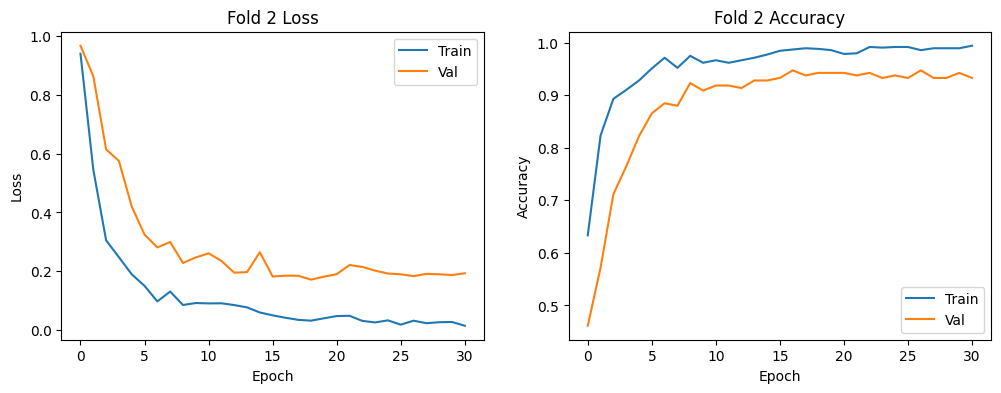


>>> Test Accuracy Fold 2: 0.9655
               precision    recall  f1-score   support

  Nitrogen(N)       1.00      1.00      1.00        44
Phosphorus(P)       0.94      0.94      0.94        33
 Potassium(K)       0.95      0.95      0.95        39

     accuracy                           0.97       116
    macro avg       0.96      0.96      0.96       116
 weighted avg       0.97      0.97      0.97       116


=============== FOLD 3/5 ===============
Epoch 1/100 | Train Loss: 0.9393 | Val Loss: 0.9488 | Val Acc: 0.4663
Epoch 2/100 | Train Loss: 0.5202 | Val Loss: 1.0775 | Val Acc: 0.4808
Epoch 3/100 | Train Loss: 0.3208 | Val Loss: 1.0017 | Val Acc: 0.5481
Epoch 4/100 | Train Loss: 0.2307 | Val Loss: 0.6803 | Val Acc: 0.7019
Epoch 5/100 | Train Loss: 0.1681 | Val Loss: 0.5047 | Val Acc: 0.7981
Epoch 6/100 | Train Loss: 0.1482 | Val Loss: 0.4471 | Val Acc: 0.8269
Epoch 7/100 | Train Loss: 0.1329 | Val Loss: 0.3274 | Val Acc: 0.8702
Epoch 8/100 | Train Loss: 0.1090 | Val Loss: 0

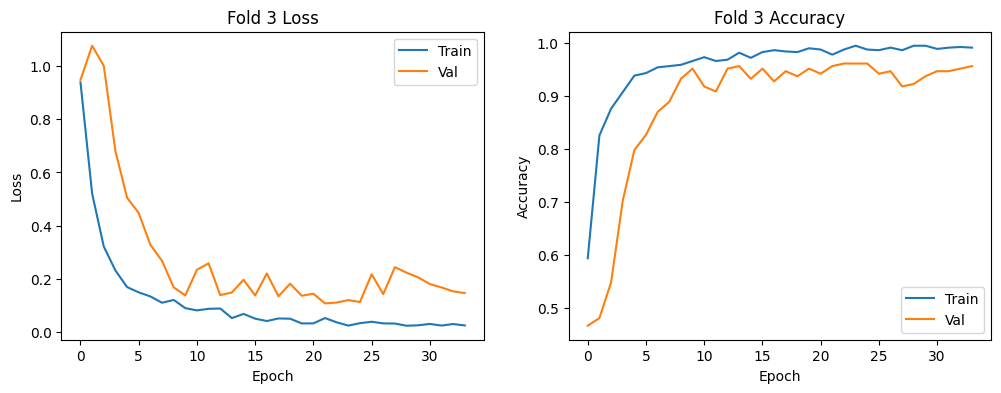


>>> Test Accuracy Fold 3: 0.9741
               precision    recall  f1-score   support

  Nitrogen(N)       1.00      1.00      1.00        44
Phosphorus(P)       0.94      0.97      0.96        33
 Potassium(K)       0.97      0.95      0.96        39

     accuracy                           0.97       116
    macro avg       0.97      0.97      0.97       116
 weighted avg       0.97      0.97      0.97       116


=============== FOLD 4/5 ===============
Epoch 1/100 | Train Loss: 0.9404 | Val Loss: 0.9300 | Val Acc: 0.5385
Epoch 2/100 | Train Loss: 0.5307 | Val Loss: 0.8708 | Val Acc: 0.5577
Epoch 3/100 | Train Loss: 0.3065 | Val Loss: 0.6496 | Val Acc: 0.6875
Epoch 4/100 | Train Loss: 0.2001 | Val Loss: 0.6077 | Val Acc: 0.7452
Epoch 5/100 | Train Loss: 0.1762 | Val Loss: 0.5824 | Val Acc: 0.7308
Epoch 6/100 | Train Loss: 0.1572 | Val Loss: 0.3734 | Val Acc: 0.8702
Epoch 7/100 | Train Loss: 0.1423 | Val Loss: 0.3355 | Val Acc: 0.8558
Epoch 8/100 | Train Loss: 0.0994 | Val Loss: 0

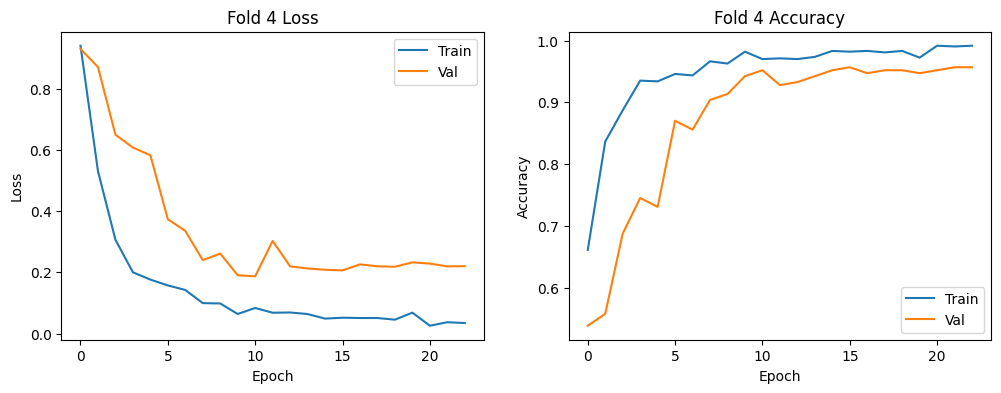


>>> Test Accuracy Fold 4: 0.9483
               precision    recall  f1-score   support

  Nitrogen(N)       0.98      1.00      0.99        44
Phosphorus(P)       0.91      0.91      0.91        33
 Potassium(K)       0.95      0.92      0.94        39

     accuracy                           0.95       116
    macro avg       0.94      0.94      0.94       116
 weighted avg       0.95      0.95      0.95       116


=============== FOLD 5/5 ===============
Epoch 1/100 | Train Loss: 0.9638 | Val Loss: 0.9386 | Val Acc: 0.5529
Epoch 2/100 | Train Loss: 0.5571 | Val Loss: 0.8978 | Val Acc: 0.6106
Epoch 3/100 | Train Loss: 0.3080 | Val Loss: 1.0013 | Val Acc: 0.5337
Epoch 4/100 | Train Loss: 0.2378 | Val Loss: 0.5411 | Val Acc: 0.7692
Epoch 5/100 | Train Loss: 0.1980 | Val Loss: 0.4391 | Val Acc: 0.8221
Epoch 6/100 | Train Loss: 0.1709 | Val Loss: 0.2956 | Val Acc: 0.8750
Epoch 7/100 | Train Loss: 0.1997 | Val Loss: 0.3741 | Val Acc: 0.8750
Epoch 8/100 | Train Loss: 0.1118 | Val Loss: 0

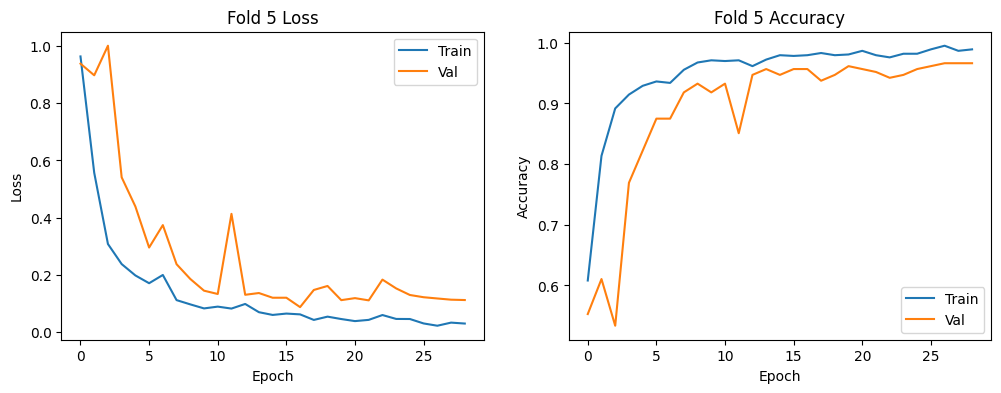


>>> Test Accuracy Fold 5: 0.9569
               precision    recall  f1-score   support

  Nitrogen(N)       1.00      1.00      1.00        44
Phosphorus(P)       0.89      0.97      0.93        33
 Potassium(K)       0.97      0.90      0.93        39

     accuracy                           0.96       116
    macro avg       0.95      0.96      0.95       116
 weighted avg       0.96      0.96      0.96       116



In [8]:
# ===================== 7. K-FOLD LOOP =====================
for train_idx, val_idx in skf.split(np.zeros(len(trainval_labels)), trainval_labels):
    print(f"\n{'='*15} FOLD {fold}/{n_splits} {'='*15}")

    # Map index sang 2 dataset song song (train vs eval)
    train_subset = Subset(ds_full_train, trainval_idx[train_idx])
    val_subset   = Subset(ds_full_eval,   trainval_idx[val_idx])

    train_loader = DataLoader(train_subset, batch_size=batch_size,
                              shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_subset,   batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)

    # Model mới cho mỗi fold
    model = create_mobilenetv3_partial(num_classes=3, unfreeze_last_n_blocks=3).to(device)

    # Chỉ tối ưu tham số trainable (classifier)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    opt = optim.AdamW(trainable_params, lr=base_lr, weight_decay=1e-4)

    # Scheduler giảm LR khi val_loss không cải thiện
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.1, patience=5
    )

    criterion = nn.CrossEntropyLoss()
    earlystop = EarlyStopping(patience=12)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float("inf")
    best_state = None

    # ----- BIẾN LƯU TRAIN TIME TRONG FOLD NÀY -----
    fold_train_time_sum = 0.0
    fold_epoch_count = 0

    # --------- EPOCH LOOP ---------
    for epoch in range(num_epochs):

        # ===== ĐO THỜI GIAN TRAIN =====
        if device == "cuda":
            torch.cuda.synchronize()
        train_start = time.time()

        # ----- TRAIN -----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad()

            if use_amp:
                with torch.amp.autocast("cuda"):
                    out = model(x)
                    loss = criterion(out, y)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                out = model(x)
                loss = criterion(out, y)
                loss.backward()
                opt.step()

            running_loss += loss.item()
            preds = torch.argmax(out, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # ===== KẾT THÚC ĐO TRAIN TIME =====
        if device == "cuda":
            torch.cuda.synchronize()
        train_time = time.time() - train_start

        # CỘNG DỒN VÀ ĐẾM EPOCH
        fold_train_time_sum += train_time
        fold_epoch_count += 1

        # ----- VALIDATION -----
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                if use_amp:
                    with torch.amp.autocast("cuda"):
                        out = model(x)
                        loss = criterion(out, y)
                else:
                    out = model(x)
                    loss = criterion(out, y)

                val_loss_sum += loss.item()
                preds = torch.argmax(out, dim=1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        val_loss = val_loss_sum / len(val_loader)
        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Ở đây KHÔNG in train_time từng epoch nữa
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # Scheduler & EarlyStopping
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())

        earlystop(val_loss)
        if earlystop.stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # ===== SAU KHI KẾT THÚC FOLD → IN TRAIN TIME TRUNG BÌNH / EPOCH =====
    avg_train_time_epoch = fold_train_time_sum / fold_epoch_count
    print(f">>> Fold {fold}: Average train time / epoch = {avg_train_time_epoch:.2f} sec")

    # ----- PLOT CURVES -----
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.title(f"Fold {fold} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.title(f"Fold {fold} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # ----- TEST EVALUATION -----
    model.load_state_dict(best_state)
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            if use_amp:
                with torch.amp.autocast("cuda"):
                    out = model(x)
            else:
                out = model(x)

            pred = torch.argmax(out, dim=1).cpu().numpy()
            y_pred.extend(pred)
            y_true.extend(y.numpy())

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    print(f"\n>>> Test Accuracy Fold {fold}: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=ds_full_eval.classes))

    results.append(acc)

    if acc > best_overall_acc:
        best_overall_acc = acc
        best_overall_state = best_state
        best_overall_fold = fold

    fold += 1


In [9]:
# ===================== 8. FINAL SUMMARY =====================

torch.save(best_overall_state, "best_mobilenetv3_overall.pth")
avg_acc = np.mean(results)
miss_rate = 1 - avg_acc

print(f"\n{'='*20} FINAL SUMMARY {'='*20}")
print(f"Average 5-Fold Accuracy: {avg_acc:.4f}")
print(f"Miss-classification Rate: {miss_rate:.4f}")
print(f"Best Fold: {best_overall_fold} with Accuracy: {best_overall_acc:.4f}")
print("Saved best model to: best_mobilenetv3_overall.pth")

tmp_model = create_mobilenetv3_partial(num_classes=3, unfreeze_last_n_blocks=2)
total_params = sum(p.numel() for p in tmp_model.parameters())
trainable_params = sum(p.numel() for p in tmp_model.parameters() if p.requires_grad)

print("\n========== MODEL PARAMS ==========")
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print("Best Model Saved → best_mobilenetv3_overall.pth")


==================== FINAL SUMMARY ====================
Average 5-Fold Accuracy: 0.9621
Miss-classification Rate: 0.0379
Best Fold: 3 with Accuracy: 0.9741
Saved best model to: best_mobilenetv3_overall.pth

========== MODEL PARAMS ==========
Total Parameters:      4,205,875  (4.21 M)
Trainable Parameters:  2,186,803  (2.19 M)
Best Model Saved → best_mobilenetv3_overall.pth



DETAILED TEST SET ANALYSIS (BEST MobileNetV3 MODEL)

Test Set Summary (Best Model):
  Total samples:         116
  Correct predictions:   113 (97.41%)
  Wrong predictions:     3 (2.59%)

WRONG PREDICTIONS (FIRST 30):
Idx    True Label           Predicted            Confidence  
----------------------------------------------------------------------
3      Potassium(K)         Phosphorus(P)            64.79%
59     Phosphorus(P)        Potassium(K)             99.37%
85     Potassium(K)         Phosphorus(P)            69.19%

========================= VISUALIZE ALL MISCLASSIFIED TEST IMAGES =========================
Number of misclassified images: 3


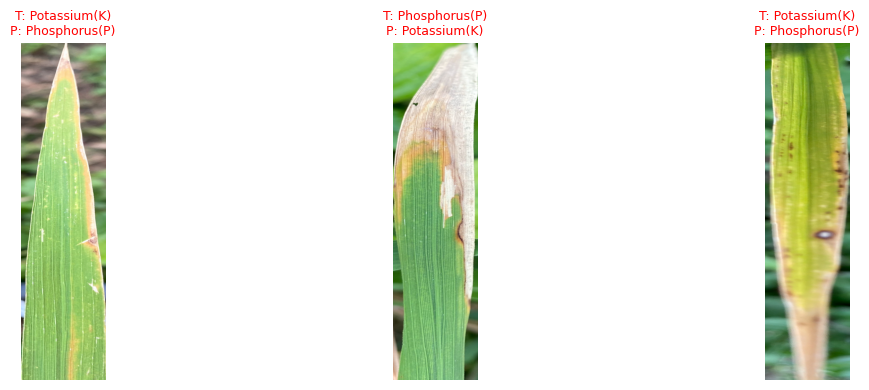

In [10]:
def denormalize(img):
    """
    img: tensor (3, H, W) đã normalize theo mean/std ImageNet
    Trả về tensor đã khử normalize, clamp về [0,1]
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    return img.clamp(0, 1)

# ==================== DETAILED TEST SET ANALYSIS (BEST MobileNetV3) ====================
print(f"\n{'='*60}")
print("DETAILED TEST SET ANALYSIS (BEST MobileNetV3 MODEL)")
print(f"{'='*60}")

# 1. Load lại best model (từ biến best_overall_state đã lưu trong K-Fold)
best_model = create_mobilenetv3_partial(num_classes=len(ds_full_eval.classes),
                                        unfreeze_last_n_blocks=3).to(device)
best_model.load_state_dict(best_overall_state)
best_model.eval()

y_true, y_pred, y_probs = [], [], []

# 2. Chạy trên toàn bộ test set, đồng thời gom các ảnh dự đoán sai
wrong_imgs = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x_device = x.to(device, non_blocking=True)

        if use_amp:
            with torch.amp.autocast("cuda"):
                out = best_model(x_device)
        else:
            out = best_model(x_device)

        probs = torch.softmax(out, dim=1)        # (batch, num_classes)
        preds = torch.argmax(probs, dim=1).cpu() # (batch,)
        y_cpu = y.cpu()

        # Lưu cho thống kê chung
        y_true.extend(y_cpu.numpy())
        y_pred.extend(preds.numpy())
        y_probs.extend(probs.cpu().numpy())

        # Lưu TẤT CẢ ảnh bị dự đoán sai
        for i in range(len(y_cpu)):
            if preds[i] != y_cpu[i]:
                wrong_imgs.append(x[i].cpu())            # ảnh đã normalize
                wrong_true.append(y_cpu[i].item())       # index class đúng
                wrong_pred.append(preds[i].item())       # index class dự đoán

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# 3. Thống kê tổng quan
total = len(y_true)
num_correct = np.sum(y_true == y_pred)
num_wrong = total - num_correct

print(f"\nTest Set Summary (Best Model):")
print(f"  Total samples:         {total}")
print(f"  Correct predictions:   {num_correct} ({num_correct/total*100:.2f}%)")
print(f"  Wrong predictions:     {num_wrong} ({num_wrong/total*100:.2f}%)")

# 4. In bảng chi tiết (tối đa 30 dòng) cho dễ đọc trên console
wrong_indices = np.where(y_true != y_pred)[0]

if len(wrong_indices) > 0:
    print(f"\n{'='*70}")
    print("WRONG PREDICTIONS (FIRST 30):")
    print(f"{'='*70}")
    print(f"{'Idx':<6} {'True Label':<20} {'Predicted':<20} {'Confidence':<12}")
    print("-" * 70)

    for idx in wrong_indices[:30]:
        true_label_name = ds_full_eval.classes[y_true[idx]]
        pred_label_name = ds_full_eval.classes[y_pred[idx]]
        conf = y_probs[idx][y_pred[idx]] * 100.0
        print(f"{idx:<6} {true_label_name:<20} {pred_label_name:<20} {conf:>9.2f}%")

    if len(wrong_indices) > 30:
        print(f"\n... and {len(wrong_indices) - 30} more wrong predictions")

# 5. VẼ TẤT CẢ ẢNH TEST BỊ DỰ ĐOÁN SAI
print(f"\n{'='*25} VISUALIZE ALL MISCLASSIFIED TEST IMAGES {'='*25}")
print(f"Number of misclassified images: {len(wrong_imgs)}")

if len(wrong_imgs) == 0:
    print("🎉 No misclassified samples found! Model classified all test images correctly.")
else:
    import math

    cols = 4  # số cột trong grid
    rows = math.ceil(len(wrong_imgs) / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))

    for idx in range(len(wrong_imgs)):
        img = denormalize(wrong_imgs[idx])          # khử normalize
        img = img.permute(1, 2, 0).numpy()          # (H, W, 3)

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.axis("off")

        true_name = ds_full_eval.classes[wrong_true[idx]]
        pred_name = ds_full_eval.classes[wrong_pred[idx]]
        plt.title(f"T: {true_name}\nP: {pred_name}", color="red", fontsize=9)

    plt.tight_layout()
    plt.show()

# Cleanup
del best_model
if device == "cuda":
    torch.cuda.empty_cache()
